In [10]:
using IonSim
using QuantumOptics
using PyPlot

In [11]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
ϵ_vec = (x̂ + ŷ) / √2

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13

# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\jewoo\.julia\packages\SciMLBase\pzpcE\src\integrator_interface.jl:626


81×81 Matrix{Float64}:
 4.03776e-15  8.89675e-15  1.92148e-14  …  8.89363e-15  4.03631e-15
 8.89645e-15  1.96023e-14  4.23362e-14     1.95954e-14  8.89325e-15
 1.92135e-14  4.23347e-14  9.14327e-14     4.23199e-14  1.92066e-14
 4.06734e-14  8.96191e-14  1.93555e-13     8.95877e-14  4.06588e-14
 8.43973e-14  1.8596e-13   4.01627e-13     1.85895e-13  8.43669e-14
 1.71657e-13  3.78226e-13  8.16875e-13  …  3.78093e-13  1.71595e-13
 3.42221e-13  7.54045e-13  1.62855e-12     7.5378e-13   3.42098e-13
 6.68755e-13  1.47352e-12  3.18245e-12     1.47301e-12  6.68515e-13
 1.28098e-12  2.82249e-12  6.09588e-12     2.8215e-12   1.28052e-12
 2.40508e-12  5.29932e-12  1.14452e-11     5.29747e-12  2.40422e-12
 ⋮                                      ⋱               ⋮
 1.27773e-12  2.81533e-12  6.08041e-12     2.81434e-12  1.27727e-12
 6.67005e-13  1.46967e-12  3.17413e-12     1.46916e-12  6.66766e-13
 3.41299e-13  7.52012e-13  1.62416e-12     7.51749e-13  3.41176e-13
 1.7118e-13   3.77176e-13  8.14608e

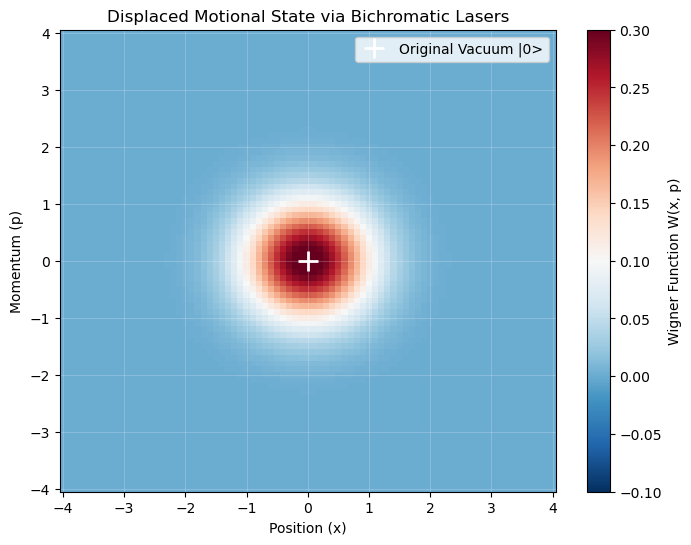

In [12]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [13]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.5im+0.5

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = I_spin ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * sol[end]

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.0e6, axis=ẑ, N=10)]
   0.5491947498992258 - 0.00060257959029835im
   0.5522096794274531 - 0.00049509584958524im
  0.27480419307935583 + 0.27431709290876793im
   0.2762924485240812 + 0.27581888327828685im
  0.00013122304835629 + 0.19411768145124397im
   0.0001596677164834 + 0.19516610630451356im
 -0.05600342849541074 + 0.05605542784772744im
 -0.05628578221185501 + 0.05637339758583969im
 -0.02801094879293714 + 7.03550391139e-6im
 -0.02815979525843946 + 2.073992204968e-5im
                      ⋮
    -1.67484395814e-6 - 0.002569714934506im
  0.00048322813746048 - 0.0004828486076754im
  0.00048524824096135 - 0.00048583886841203im
  0.00017076716475123 + 1.0407001453e-7im
  0.00017164569199057 - 9.678402311e-8im
    2.838577759267e-5 + 2.843266937833e-5im
    2.856903410015e-5 + 2.853939104032e-5im
       -9.96456905e-9 + 9.37504447026e-6im
         4.4193812e-9 + 9.42247465813e-6im

In [14]:
final_state = displaced_final_state

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)

81×81 Matrix{Float64}:
  3.91551e-15   6.2494e-15    9.75971e-15  …  -1.86231e-14  -1.25221e-14
  6.24962e-15   9.9219e-15    1.54353e-14     -4.36928e-14  -2.87142e-14
  9.76062e-15   1.54362e-14   2.39807e-14     -9.61439e-14  -6.21578e-14
  1.48975e-14   2.35068e-14   3.65745e-14     -2.00759e-13  -1.28157e-13
  2.21707e-14   3.49565e-14   5.4643e-14      -3.99958e-13  -2.52712e-13
  3.20502e-14   5.05483e-14   7.96252e-14  …  -7.61376e-13  -4.77027e-13
  4.47309e-14   7.05708e-14   1.12308e-13     -1.38259e-12  -8.6039e-13
  5.9675e-14    9.39858e-14   1.51343e-13     -2.38216e-12  -1.47521e-12
  7.48153e-14   1.16878e-13   1.90383e-13     -3.85156e-12  -2.37996e-12
  8.53202e-14   1.2993e-13    2.1316e-13      -5.71453e-12  -3.54017e-12
  ⋮                                        ⋱                 ⋮
  1.31398e-12   2.54001e-12   4.84978e-12      2.353e-8      1.22971e-8
  6.5704e-13    1.24016e-12   2.31405e-12      1.41181e-8    7.37637e-9
  2.8623e-13    5.15836e-13   9.18477e-13

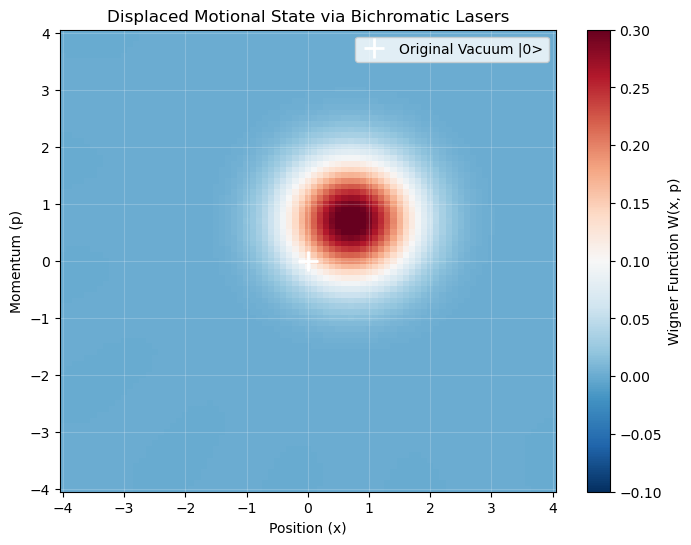

In [15]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [27]:
# ---------------------------------------------------------
# DIAGNOSTIC 3: Motional State (Phonon) Evolution
# ---------------------------------------------------------
print(typeof(rho_fock))
b_fock_debug = FockBasis(mode_z.N)
a_op = QuantumOptics.destroy(b_fock_debug)
n_op = QuantumOptics.number(b_fock_debug)
x_op = (dagger(a_op) + a_op) / sqrt(2)
p_op = 1im * (dagger(a_op) - a_op) / sqrt(2)

phonon_tracking = Float64[]
x_tracking = Float64[]
p_tracking = Float64[]

for state in sol
    rho_m = ptrace(final_state, 1)
    rho_f = DenseOperator(b_fock_debug, rho_m.data)
    
    push!(phonon_tracking, real(expect(n_op, rho_f)))
    push!(x_tracking, real(expect(x_op, rho_f)))
    push!(p_tracking, real(expect(p_op, rho_f)))
end

println("\n[DIAGNOSTIC 3] Motional Growth")
println("Phonons at t = 0 μs   : ", phonon_tracking[1])
println("Phonons at t = 100 μs : ", phonon_tracking[end])
println("Max Phonons reached   : ", maximum(phonon_tracking))

println("\n[DIAGNOSTIC 6] Phase Space Translation")
println("Max Position <x> shifted: ", maximum(abs.(x_tracking)))
println("Max Momentum <p> shifted: ", maximum(abs.(p_tracking)))
# ---------------------------------------------------------
# DIAGNOSTIC 4: Internal Spin State Integrity
# ---------------------------------------------------------
P_e = ionprojector(trap, "e")
e_pops = real.(expect(P_e, sol))
max_deviation = maximum(abs.(e_pops .- 0.5))

println("\n[DIAGNOSTIC 4] Spin State Dynamics")
println("Initial |e> population : ", e_pops[1])
println("Final |e> population   : ", e_pops[end])
println("Max deviation from 0.5 : ", max_deviation)

# ---------------------------------------------------------
# DIAGNOSTIC 5: Motional State Purity
# ---------------------------------------------------------
purity_tracking = [real(tr(ptrace(final_state, 1)^2)) for state in sol]
println("\n[DIAGNOSTIC 5] Motional State Purity")
println("Initial Purity : ", purity_tracking[1])
println("Final Purity   : ", purity_tracking[end])
println("="^50 * "\n")

Operator{FockBasis{Int64}, FockBasis{Int64}, Matrix{ComplexF64}}
[DIAGNOSTIC 3] Motional Growth
Phonons at t = 0 μs   : 0.49978256625576223
Phonons at t = 100 μs : 0.49978256625576223
Max Phonons reached   : 0.49978256625576223

[DIAGNOSTIC 6] Phase Space Translation
Max Position <x> shifted: 0.706821694841197
Max Momentum <p> shifted: 0.7069976469048834

[DIAGNOSTIC 4] Spin State Dynamics
Initial |e> population : 0.4999999999999999
Final |e> population   : 0.5026645823848491
Max deviation from 0.5 : 0.003092728370398312

[DIAGNOSTIC 5] Motional State Purity
Initial Purity : 0.9997548136225975
Final Purity   : 0.9997548136225975



In [33]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
ϵ_vec = (x̂ + ŷ) / √2

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
# transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
transition_λ = transitionwavelength(ion, ("g", "e"), trap)
B_field = 1e-13

# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:50.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


81×81 Matrix{Float64}:
 1.29858e-6  2.0481e-6   3.1493e-6    …  3.15316e-6   2.05045e-6  1.29998e-6
 2.15722e-6  3.36492e-6  5.11279e-6      5.11852e-6   3.36845e-6  2.15935e-6
 3.5155e-6   5.42136e-6  8.13605e-6      8.14413e-6   5.42638e-6  3.51856e-6
 5.62256e-6  8.56942e-6  1.26967e-5      1.27073e-5   8.57613e-6  5.62671e-6
 8.82978e-6  1.32964e-5  1.94415e-5      1.94541e-5   1.33045e-5  8.83492e-6
 1.36229e-5  2.02634e-5  2.92286e-5   …  2.92411e-5   2.02717e-5  1.36284e-5
 2.06614e-5  3.03513e-5  4.31767e-5      4.31838e-5   3.03567e-5  2.06655e-5
 3.0825e-5   4.47148e-5  6.27211e-5      6.27126e-5   4.4711e-5   3.08239e-5
 4.52699e-5  6.48469e-5  8.96833e-5      8.964e-5     6.48221e-5  4.52566e-5
 6.54954e-5  9.26568e-5  0.000126356     0.000126246  9.25905e-5  6.54574e-5
 ⋮                                    ⋱                           ⋮
 4.52566e-5  6.48221e-5  8.964e-5        8.96833e-5   6.48469e-5  4.52699e-5
 3.08239e-5  4.4711e-5   6.27126e-5      6.27211e-5   4.47148e

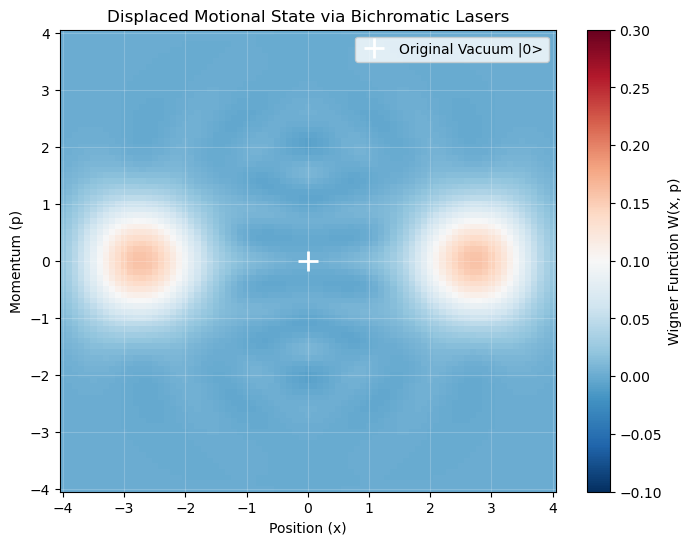

In [34]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [35]:
# ---------------------------------------------------------
# DIAGNOSTIC 3: Motional State (Phonon) Evolution
# ---------------------------------------------------------
print(typeof(rho_fock))
b_fock_debug = FockBasis(mode_z.N)
a_op = QuantumOptics.destroy(b_fock_debug)
n_op = QuantumOptics.number(b_fock_debug)
x_op = (dagger(a_op) + a_op) / sqrt(2)
p_op = 1im * (dagger(a_op) - a_op) / sqrt(2)

phonon_tracking = Float64[]
x_tracking = Float64[]
p_tracking = Float64[]

for state in sol
    rho_m = ptrace(final_state, 1)
    rho_f = DenseOperator(b_fock_debug, rho_m.data)
    
    push!(phonon_tracking, real(expect(n_op, rho_f)))
    push!(x_tracking, real(expect(x_op, rho_f)))
    push!(p_tracking, real(expect(p_op, rho_f)))
end

println("\n[DIAGNOSTIC 3] Motional Growth")
println("Phonons at t = 0 μs   : ", phonon_tracking[1])
println("Phonons at t = 100 μs : ", phonon_tracking[end])
println("Max Phonons reached   : ", maximum(phonon_tracking))

println("\n[DIAGNOSTIC 6] Phase Space Translation")
println("Max Position <x> shifted: ", maximum(abs.(x_tracking)))
println("Max Momentum <p> shifted: ", maximum(abs.(p_tracking)))
# ---------------------------------------------------------
# DIAGNOSTIC 4: Internal Spin State Integrity
# ---------------------------------------------------------
P_e = ionprojector(trap, "e")
e_pops = real.(expect(P_e, sol))
max_deviation = maximum(abs.(e_pops .- 0.5))

println("\n[DIAGNOSTIC 4] Spin State Dynamics")
println("Initial |e> population : ", e_pops[1])
println("Final |e> population   : ", e_pops[end])
println("Max deviation from 0.5 : ", max_deviation)

# ---------------------------------------------------------
# DIAGNOSTIC 5: Motional State Purity
# ---------------------------------------------------------
purity_tracking = [real(tr(ptrace(final_state, 1)^2)) for state in sol]
println("\n[DIAGNOSTIC 5] Motional State Purity")
println("Initial Purity : ", purity_tracking[1])
println("Final Purity   : ", purity_tracking[end])
println("="^50 * "\n")

Operator{FockBasis{Int64}, FockBasis{Int64}, Matrix{ComplexF64}}
[DIAGNOSTIC 3] Motional Growth
Phonons at t = 0 μs   : 3.733688800010161
Phonons at t = 100 μs : 3.733688800010161
Max Phonons reached   : 3.733688800010161

[DIAGNOSTIC 6] Phase Space Translation
Max Position <x> shifted: 0.0
Max Momentum <p> shifted: 0.0

[DIAGNOSTIC 4] Spin State Dynamics
Initial |e> population : 0.4999999999999999
Final |e> population   : 0.5000065402446247
Max deviation from 0.5 : 6.540244624653191e-6

[DIAGNOSTIC 5] Motional State Purity
Initial Purity : 0.5000455158691154
Final Purity   : 0.5000455158691154



In [36]:
final_state = displaced_final_state

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec) 

81×81 Matrix{Float64}:
  3.91551e-15   6.2494e-15    9.75971e-15  …  -1.86231e-14  -1.25221e-14
  6.24962e-15   9.9219e-15    1.54353e-14     -4.36928e-14  -2.87142e-14
  9.76062e-15   1.54362e-14   2.39807e-14     -9.61439e-14  -6.21578e-14
  1.48975e-14   2.35068e-14   3.65745e-14     -2.00759e-13  -1.28157e-13
  2.21707e-14   3.49565e-14   5.4643e-14      -3.99958e-13  -2.52712e-13
  3.20502e-14   5.05483e-14   7.96252e-14  …  -7.61376e-13  -4.77027e-13
  4.47309e-14   7.05708e-14   1.12308e-13     -1.38259e-12  -8.6039e-13
  5.9675e-14    9.39858e-14   1.51343e-13     -2.38216e-12  -1.47521e-12
  7.48153e-14   1.16878e-13   1.90383e-13     -3.85156e-12  -2.37996e-12
  8.53202e-14   1.2993e-13    2.1316e-13      -5.71453e-12  -3.54017e-12
  ⋮                                        ⋱                 ⋮
  1.31398e-12   2.54001e-12   4.84978e-12      2.353e-8      1.22971e-8
  6.5704e-13    1.24016e-12   2.31405e-12      1.41181e-8    7.37637e-9
  2.8623e-13    5.15836e-13   9.18477e-13

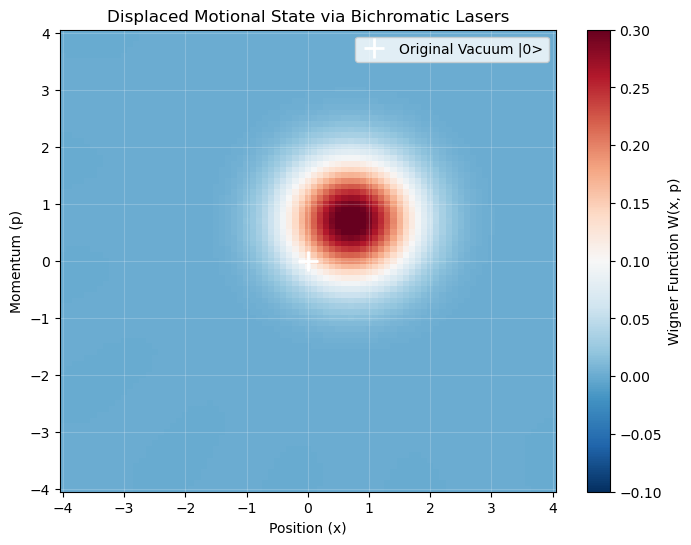

In [37]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
